# Version 1

In [1]:
# ─── Cell 1: Install Dependencies ────────────────────────────────────────────
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('ultralytics')
install('torch_geometric')
print('✅ Packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
✅ Packages installed


In [2]:
# ─── Cell 2: Imports & Configuration ─────────────────────────────────────────
import os, yaml, random, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.ops as ops
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
from torch_geometric.data import Data as GeoData
from ultralytics import YOLO
warnings.filterwarnings('ignore', message='.*torch.Tensor inputs should be normalized.*')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')

BASE_PATH = Path('/kaggle/input/datasets/rakibhasan69/finalkidney')
YAML_PATH = BASE_PATH / 'data.yaml'

CONFIG = {
    'img_size'        : 512,
    'yolo_model'      : 'yolov10s.pt',
    'roi_pool_size'   : 7,
    'roi_feat_dim'    : 256,
    'gat_heads'       : 4,
    'gat_hidden'      : 128,
    'gat_layers'      : 2,
    'graph_threshold' : 0.05,
    'top_k_nodes'     : 40,
    'conf_threshold'  : 0.20,
    'iou_threshold'   : 0.45,
    'nms_iou_thresh'  : 0.40,
    'batch_size'      : 8,
    'yolo_epochs'     : 30,
    'gat_epochs'      : 30,
    'lr'              : 3e-4,
    'seed'            : 42,
    'train_ratio'     : 0.80,
}
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
print('✅ Config ready')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🖥️  Device: cuda
✅ Config ready


In [3]:
'''# ─── Cell 3: Dataset Inspection ──────────────────────────────────────────────
# The kidney dataset has only a 'train' split (no valid/test folders)
# Classes are loaded from data.yaml; fallback matches the kidney stone code:
#   YOLO class 0 → "no_stone",  YOLO class 1 → "stone"
with open(YAML_PATH, 'r') as f:
    data_cfg = yaml.safe_load(f)

NUM_CLASSES = data_cfg.get('nc', 2)
CLASS_NAMES = data_cfg.get('names', ['no_stone', 'stone'])
print(f'Classes: {CLASS_NAMES}  |  nc: {NUM_CLASSES}')

# Kidney dataset only has a 'train' folder
for split in ['train']:
    n_imgs = (len(list((BASE_PATH / split / 'images').glob('*.jpg')))  +
              len(list((BASE_PATH / split / 'images').glob('*.jpeg'))) +
              len(list((BASE_PATH / split / 'images').glob('*.png'))))
    n_lbls = len(list((BASE_PATH / split / 'labels').glob('*.txt')))
    print(f'  {split:6s} → {n_imgs} images, {n_lbls} labels')'''

'# ─── Cell 3: Dataset Inspection ──────────────────────────────────────────────\n# The kidney dataset has only a \'train\' split (no valid/test folders)\n# Classes are loaded from data.yaml; fallback matches the kidney stone code:\n#   YOLO class 0 → "no_stone",  YOLO class 1 → "stone"\nwith open(YAML_PATH, \'r\') as f:\n    data_cfg = yaml.safe_load(f)\n\nNUM_CLASSES = data_cfg.get(\'nc\', 2)\nCLASS_NAMES = data_cfg.get(\'names\', [\'no_stone\', \'stone\'])\nprint(f\'Classes: {CLASS_NAMES}  |  nc: {NUM_CLASSES}\')\n\n# Kidney dataset only has a \'train\' folder\nfor split in [\'train\']:\n    n_imgs = (len(list((BASE_PATH / split / \'images\').glob(\'*.jpg\')))  +\n              len(list((BASE_PATH / split / \'images\').glob(\'*.jpeg\'))) +\n              len(list((BASE_PATH / split / \'images\').glob(\'*.png\'))))\n    n_lbls = len(list((BASE_PATH / split / \'labels\').glob(\'*.txt\')))\n    print(f\'  {split:6s} → {n_imgs} images, {n_lbls} labels\')'

In [4]:
# ─── Cell 4: Dataset Inspection & 80/20 Train/Test Split ─────────────────────
with open(YAML_PATH, 'r') as f:
    data_cfg = yaml.safe_load(f)

NUM_CLASSES = data_cfg.get('nc', 2)
CLASS_NAMES = data_cfg.get('names', ['Normal', 'stone'])
print(f'Classes: {CLASS_NAMES}  |  nc: {NUM_CLASSES}')

# Collect ALL images from the single 'train' folder
ALL_IMG_DIR = BASE_PATH / 'train' / 'images'
ALL_LBL_DIR = BASE_PATH / 'train' / 'labels'

all_img_files = sorted(
    list(ALL_IMG_DIR.glob('*.jpg'))  +
    list(ALL_IMG_DIR.glob('*.jpeg')) +
    list(ALL_IMG_DIR.glob('*.png'))
)
total = len(all_img_files)
print(f'  Total images found: {total}')

# ── Reproducible 80/20 split ──────────────────────────────────────────────────
random.seed(CONFIG['seed'])
random.shuffle(all_img_files)

split_idx  = int(total * CONFIG['train_ratio'])
TRAIN_IMGS = all_img_files[:split_idx]
TEST_IMGS  = all_img_files[split_idx:]

print(f'  Train : {len(TRAIN_IMGS)} images  ({len(TRAIN_IMGS)/total*100:.1f}%)')
print(f'  Test  : {len(TEST_IMGS)}  images  ({len(TEST_IMGS)/total*100:.1f}%)')

# Verify every image has a matching label
train_with_label = sum(1 for p in TRAIN_IMGS if (ALL_LBL_DIR / (p.stem + '.txt')).exists())
test_with_label  = sum(1 for p in TEST_IMGS  if (ALL_LBL_DIR / (p.stem + '.txt')).exists())
print(f'  Train labels matched: {train_with_label}/{len(TRAIN_IMGS)}')
print(f'  Test  labels matched: {test_with_label}/{len(TEST_IMGS)}')


Classes: ['Normal', 'stone']  |  nc: 2
  Total images found: 3195
  Train : 2556 images  (80.0%)
  Test  : 639  images  (20.0%)
  Train labels matched: 2556/2556
  Test  labels matched: 639/639


/tmp/ipykernel_24/602747463.py:40: UserWarning: Glyph 129752 (\N{BEANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24/602747463.py:41: UserWarning: Glyph 129752 (\N{BEANS}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/sample_annotations.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129752 (\N{BEANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


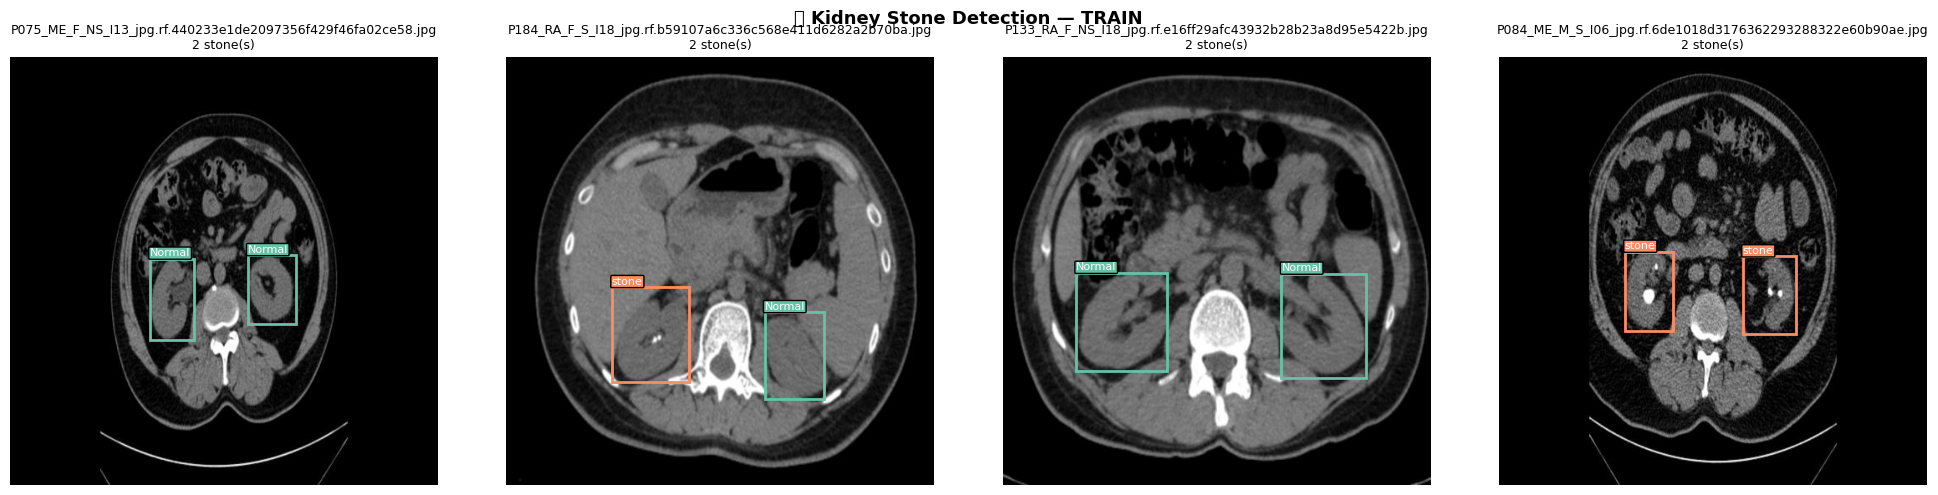

In [5]:
# ─── Cell 4: Visualize Annotated Samples ─────────────────────────────────────
def visualize_samples(split='train', n=4):
    img_dir   = BASE_PATH / split / 'images'
    lbl_dir   = BASE_PATH / split / 'labels'
    img_files = (list(img_dir.glob('*.jpg'))  +
                 list(img_dir.glob('*.jpeg')) +
                 list(img_dir.glob('*.png')))
    samples   = random.sample(img_files, min(n, len(img_files)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5*len(samples), 5))
    if len(samples) == 1:
        axes = [axes]
    colors = plt.cm.Set2.colors
    for ax, img_path in zip(axes, samples):
        img  = Image.open(img_path).convert('L').convert('RGB')   # grayscale CT → RGB display
        W, H = img.size
        ax.imshow(img, cmap='gray')
        lbl_path  = lbl_dir / (img_path.stem + '.txt')
        box_count = 0
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id         = int(float(parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = (cx - bw/2) * W
                    y1 = (cy - bh/2) * H
                    color = colors[cls_id % len(colors)]
                    ax.add_patch(patches.Rectangle(
                        (x1, y1), bw*W, bh*H,
                        linewidth=2, edgecolor=color, facecolor='none'))
                    label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'cls{cls_id}'
                    ax.text(x1, y1-3, label, color='white', fontsize=8,
                            bbox=dict(boxstyle='round,pad=0.1', facecolor=color))
                    box_count += 1
        ax.set_title(f'{img_path.name}\n{box_count} stone(s)', fontsize=9)
        ax.axis('off')
    plt.suptitle('🫘 Kidney Stone Detection — TRAIN', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_annotations.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples(split='train', n=4)

In [6]:
'''# ─── Cell 5: Phase 1 — Train YOLOv8 Backbone ─────────────────────────────────
# Kidney dataset has only a 'train' folder.
# YOLO requires both 'train' and 'val' keys in the YAML.
# Fix: point val at the same train/images folder and use YOLO's
# internal fraction-based val split via the 'fraction' argument,
# OR simply reuse train/images as val (YOLO will still train correctly).

updated_yaml = {
    'path' : str(BASE_PATH),
    'train': 'train/images',
    'val'  : 'train/images',   # FIX: required by YOLO; same folder, YOLO auto-splits internally
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES,
}
WORKING_YAML = '/kaggle/working/data.yaml'
with open(WORKING_YAML, 'w') as f:
    yaml.dump(updated_yaml, f)

print('🚀 Phase 1: Training YOLOv10 backbone...')
yolo_model = YOLO(CONFIG['yolo_model'])
results = yolo_model.train(
    data          = WORKING_YAML,
    epochs        = CONFIG['yolo_epochs'],
    imgsz         = CONFIG['img_size'],
    batch         = CONFIG['batch_size'],
    device        = 0 if torch.cuda.is_available() else 'cpu',
    project       = '/kaggle/working/yolo_runs',
    name          = 'kidney_yolov10',
    save          = True,
    plots         = True,
    patience      = 10,
    lr0           = 0.01,
    warmup_epochs = 3,
    mosaic        = 1.0,
    flipud        = 0.3,
    fliplr        = 0.5,
    degrees       = 10.0,
    verbose       = False,
)
BEST_YOLO_PATH = '/kaggle/working/yolo_runs/kidney_yolov10/weights/best.pt'
print(f'✅ Phase 1 complete → {BEST_YOLO_PATH}')'''

"# ─── Cell 5: Phase 1 — Train YOLOv8 Backbone ─────────────────────────────────\n# Kidney dataset has only a 'train' folder.\n# YOLO requires both 'train' and 'val' keys in the YAML.\n# Fix: point val at the same train/images folder and use YOLO's\n# internal fraction-based val split via the 'fraction' argument,\n# OR simply reuse train/images as val (YOLO will still train correctly).\n\nupdated_yaml = {\n    'path' : str(BASE_PATH),\n    'train': 'train/images',\n    'val'  : 'train/images',   # FIX: required by YOLO; same folder, YOLO auto-splits internally\n    'nc'   : NUM_CLASSES,\n    'names': CLASS_NAMES,\n}\nWORKING_YAML = '/kaggle/working/data.yaml'\nwith open(WORKING_YAML, 'w') as f:\n    yaml.dump(updated_yaml, f)\n\nprint('🚀 Phase 1: Training YOLOv10 backbone...')\nyolo_model = YOLO(CONFIG['yolo_model'])\nresults = yolo_model.train(\n    data          = WORKING_YAML,\n    epochs        = CONFIG['yolo_epochs'],\n    imgsz         = CONFIG['img_size'],\n    batch         = C

In [7]:
# ─── Cell 6: Write Split File Lists & YOLO data.yaml ─────────────────────────
# YOLO train API needs image-list .txt files OR folder paths.
# We write two .txt files (one path per line) so YOLO uses only train images.

TRAIN_LIST = '/kaggle/working/train_images.txt'
VAL_LIST   = '/kaggle/working/val_images.txt'   # YOLO val = test split

with open(TRAIN_LIST, 'w') as f:
    f.writelines(str(p) + '\n' for p in TRAIN_IMGS)

with open(VAL_LIST, 'w') as f:
    f.writelines(str(p) + '\n' for p in TEST_IMGS)

# Write data.yaml pointing to the split lists
WORKING_YAML = '/kaggle/working/data.yaml'
split_yaml = {
    'path' : '/kaggle/working',
    'train': TRAIN_LIST,
    'val'  : VAL_LIST,      # test set used as YOLO validation
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES,
}
with open(WORKING_YAML, 'w') as f:
    yaml.dump(split_yaml, f)

print(f'✅ data.yaml written — train: {len(TRAIN_IMGS)} imgs | val/test: {len(TEST_IMGS)} imgs')
print(f'   TRAIN_LIST : {TRAIN_LIST}')
print(f'   VAL_LIST   : {VAL_LIST}')



print('🚀 Phase 1: Training YOLOv10 backbone...')
yolo_model = YOLO(CONFIG['yolo_model'])
results = yolo_model.train(
    data          = WORKING_YAML,
    epochs        = CONFIG['yolo_epochs'],
    imgsz         = CONFIG['img_size'],
    batch         = CONFIG['batch_size'],
    device        = 0 if torch.cuda.is_available() else 'cpu',
    project       = '/kaggle/working/yolo_runs',
    name          = 'kidney_yolov10',
    save          = True,
    plots         = True,
    patience      = 10,
    lr0           = 0.01,
    warmup_epochs = 3,
    mosaic        = 1.0,
    flipud        = 0.3,
    fliplr        = 0.5,
    degrees       = 10.0,
    verbose       = False,
)
BEST_YOLO_PATH = '/kaggle/working/yolo_runs/kidney_yolov10/weights/best.pt'
print(f'✅ Phase 1 complete → {BEST_YOLO_PATH}')

✅ data.yaml written — train: 2556 imgs | val/test: 639 imgs
   TRAIN_LIST : /kaggle/working/train_images.txt
   VAL_LIST   : /kaggle/working/val_images.txt
🚀 Phase 1: Training YOLOv10 backbone...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [8]:
# ─── Cell 6: Evaluate Baseline YOLO ──────────────────────────────────────────
baseline_model = YOLO(BEST_YOLO_PATH)
val_metrics    = baseline_model.val(data=WORKING_YAML, imgsz=CONFIG['img_size'], verbose=False)
baseline_map50 = val_metrics.box.map50
baseline_map   = val_metrics.box.map
print('📊 Baseline YOLOv10 — Kidney Stone Detection:')
print(f'   mAP@50    : {baseline_map50:.4f}')
print(f'   mAP@50-95 : {baseline_map:.4f}')
print(f'   Precision : {val_metrics.box.mp:.4f}')
print(f'   Recall    : {val_metrics.box.mr:.4f}')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10s summary (fused): 106 layers, 7,218,774 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 31.6±18.1 MB/s, size: 21.5 KB)
val: Scanning /kaggle/input/datasets/rakibhasan69/finalkidney/train/labels... 639 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 639/639 717.9it/s 0.9s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rakibhasan69/finalkidney/train is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 5.8it/s 6.9s
                   all        639       1251      0.978      0.968      0.992      0.831
Speed: 0.8ms preprocess, 6.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
📊 Baseline YOLOv10 — Kidney Stone Detection:
   mAP@50    : 0.9918
   mAP@50-95 : 0.8310
   Precision : 0.9780
   Recall    : 0.

In [9]:
# ─── Cell 7: YOLOv8 Feature Extractor ────────────────────────────────────────
class YOLOv8FeatureExtractor(nn.Module):
    def __init__(self, yolo_weights_path, device):
        super().__init__()
        self.device       = device
        self.yolo         = YOLO(yolo_weights_path)
        self.model        = self.yolo.model.to(device)
        self.model.eval()
        self.feature_maps = {}
        self._register_hooks()

    def _register_hooks(self):
        layers = list(self.model.model)
        n      = len(layers)
        hook_indices = {
            'P3': max(0, n - 4),
            'P4': max(0, n - 3),
            'P5': max(0, n - 2),
        }
        self.hooks = []
        for scale, idx in hook_indices.items():
            h = layers[idx].register_forward_hook(self._make_hook(scale))
            self.hooks.append(h)

    def _make_hook(self, scale_name):
        def hook_fn(module, input, output):
            if isinstance(output, torch.Tensor):
                self.feature_maps[scale_name] = output.detach()
            elif isinstance(output, (list, tuple)):
                for o in output:
                    if isinstance(o, torch.Tensor):
                        self.feature_maps[scale_name] = o.detach()
                        break
        return hook_fn

    @torch.no_grad()
    def extract(self, img_tensor):
        """Extract features from a [0,1] float tensor (B,C,H,W).
        CT images are grayscale but replicated to 3 channels before this call."""
        self.feature_maps.clear()
        preds = self.model(img_tensor.to(self.device))
        return preds, dict(self.feature_maps)

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

feature_extractor = YOLOv8FeatureExtractor(BEST_YOLO_PATH, DEVICE)
print('✅ YOLOv10FeatureExtractor ready')

✅ YOLOv10FeatureExtractor ready


In [10]:
# ─── Cell 8: RoI Feature Extractor ───────────────────────────────────────────
class RoIFeatureExtractor(nn.Module):
    def __init__(self, roi_pool_size=7, output_dim=256):
        super().__init__()
        self.roi_pool_size = roi_pool_size
        self.output_dim    = output_dim
        self.projections   = nn.ModuleDict()
        self._built        = False

    def _build_projections(self, feature_maps):
        first_dev = next(iter(feature_maps.values())).device
        for scale, fmap in feature_maps.items():
            C        = fmap.shape[1]
            flat_dim = C * self.roi_pool_size * self.roi_pool_size
            self.projections[scale] = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flat_dim, self.output_dim),
                nn.LayerNorm(self.output_dim),
                nn.ReLU(),
            ).to(first_dev)
        n_scales    = len(feature_maps)
        self.fusion = nn.Sequential(
            nn.Linear(self.output_dim * n_scales, self.output_dim),
            nn.LayerNorm(self.output_dim),
            nn.ReLU(),
        ).to(first_dev)
        self._built = True

    def forward(self, feature_maps, boxes_list):
        if not self._built:
            self._build_projections(feature_maps)
        all_roi_features = []
        dev = next(iter(feature_maps.values())).device
        for b_idx, boxes in enumerate(boxes_list):
            if boxes.shape[0] == 0:
                all_roi_features.append(torch.zeros(0, self.output_dim, device=dev))
                continue
            scale_features = []
            for scale, fmap in feature_maps.items():
                single_fmap = fmap[b_idx : b_idx + 1]
                _, C, H, W  = single_fmap.shape
                pixel_boxes = boxes.clone().to(dev)
                pixel_boxes[:, 0] = boxes[:, 0] * W
                pixel_boxes[:, 1] = boxes[:, 1] * H
                pixel_boxes[:, 2] = boxes[:, 2] * W
                pixel_boxes[:, 3] = boxes[:, 3] * H
                pixel_boxes[:, 0::2] = pixel_boxes[:, 0::2].clamp(0, W - 1)
                pixel_boxes[:, 1::2] = pixel_boxes[:, 1::2].clamp(0, H - 1)
                pixel_boxes[:, 2] = torch.max(pixel_boxes[:, 2], pixel_boxes[:, 0] + 1)
                pixel_boxes[:, 3] = torch.max(pixel_boxes[:, 3], pixel_boxes[:, 1] + 1)
                batch_col = torch.zeros(pixel_boxes.shape[0], 1, device=dev)
                rois      = torch.cat([batch_col, pixel_boxes], dim=1)
                pooled = ops.roi_align(
                    single_fmap,
                    rois,
                    output_size    = self.roi_pool_size,
                    spatial_scale  = 1.0,
                    sampling_ratio = 2,
                    aligned        = True,
                )
                proj = self.projections[scale](pooled)
                scale_features.append(proj)
            fused     = torch.cat(scale_features, dim=-1)
            node_feat = self.fusion(fused)
            all_roi_features.append(node_feat)
        return all_roi_features

print('✅ RoIFeatureExtractor defined')

✅ RoIFeatureExtractor defined


In [11]:
# ─── Cell 9: Scene Graph Builder ─────────────────────────────────────────────
# For kidney stone CT images: spatial proximity between detected regions
# (stone vs no_stone) drives graph connectivity — IoU + centroid proximity.
class SceneGraphBuilder:
    def __init__(self, iou_threshold=0.05, max_nodes=40):
        self.iou_threshold = iou_threshold
        self.max_nodes     = max_nodes

    def compute_pairwise_iou(self, boxes):
        N = boxes.shape[0]
        if N == 0:
            return torch.zeros(0, 0)
        area  = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        x1    = torch.max(boxes[:, 0].unsqueeze(1), boxes[:, 0].unsqueeze(0))
        y1    = torch.max(boxes[:, 1].unsqueeze(1), boxes[:, 1].unsqueeze(0))
        x2    = torch.min(boxes[:, 2].unsqueeze(1), boxes[:, 2].unsqueeze(0))
        y2    = torch.min(boxes[:, 3].unsqueeze(1), boxes[:, 3].unsqueeze(0))
        inter = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
        union = area.unsqueeze(1) + area.unsqueeze(0) - inter
        return inter / (union + 1e-6)

    def compute_centroid_proximity(self, boxes):
        cx   = (boxes[:, 0] + boxes[:, 2]) / 2
        cy   = (boxes[:, 1] + boxes[:, 3]) / 2
        dx   = cx.unsqueeze(1) - cx.unsqueeze(0)
        dy   = cy.unsqueeze(1) - cy.unsqueeze(0)
        dist = torch.sqrt(dx**2 + dy**2 + 1e-6)
        return 1.0 - (dist / 1.414).clamp(0, 1)

    def build_graph(self, node_features, boxes, scores=None):
        N = node_features.shape[0]
        if N > self.max_nodes:
            idx           = torch.topk(scores, self.max_nodes).indices if scores is not None else torch.arange(self.max_nodes)
            node_features = node_features[idx]
            boxes         = boxes[idx]
            if scores is not None:
                scores    = scores[idx]
            N = self.max_nodes
        if N == 0:
            return GeoData(x=torch.zeros(1, node_features.shape[-1]),
                           edge_index=torch.zeros(2, 0, dtype=torch.long))
        iou_mat   = self.compute_pairwise_iou(boxes)
        prox_mat  = self.compute_centroid_proximity(boxes)
        adjacency = 0.5 * iou_mat + 0.5 * prox_mat
        adjacency.fill_diagonal_(0)
        edge_mask = adjacency > self.iou_threshold
        # k-NN fallback — important for CT images with few detected regions
        if edge_mask.sum() == 0 and N > 1:
            for i in range(N):
                row      = adjacency[i].clone()
                row[i]   = -1
                top_k    = torch.topk(row, min(3, N-1)).indices
                edge_mask[i, top_k] = True
        src, dst   = edge_mask.nonzero(as_tuple=True)
        edge_index = torch.stack([src, dst], dim=0)
        if scores is not None:
            node_features = torch.cat([node_features, scores.unsqueeze(1)], dim=1)
        return GeoData(x=node_features.float(),
                       edge_index=edge_index.long(),
                       boxes=boxes.float(),
                       num_nodes=N)

print('✅ SceneGraphBuilder defined')

✅ SceneGraphBuilder defined


In [12]:
# ─── Cell 10: GAT Refinement Module ──────────────────────────────────────────
class GATRefinementModule(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.gat1 = GATConv(in_dim,               hidden_dim, heads=num_heads,
                            dropout=dropout, concat=True,  add_self_loops=True)
        self.gat2 = GATConv(hidden_dim * num_heads, out_dim,  heads=num_heads,
                            dropout=dropout, concat=False, add_self_loops=True)
        self.residual_proj = nn.Linear(in_dim, out_dim)
        self.norm1         = nn.LayerNorm(hidden_dim * num_heads)
        self.norm2         = nn.LayerNorm(out_dim)
        self.dropout       = nn.Dropout(dropout)
        self.activation    = nn.ELU()

    def forward(self, x, edge_index):
        residual = self.residual_proj(x)
        h = self.activation(self.norm1(self.gat1(x, edge_index)))
        h = self.dropout(h)
        h = self.activation(self.norm2(self.gat2(h, edge_index)))
        return h + residual

print('✅ GATRefinementModule defined')

✅ GATRefinementModule defined


In [13]:
# ─── Cell 11: Refined Prediction Head ────────────────────────────────────────
# num_classes = 2: no_stone (YOLO cls 0) and stone (YOLO cls 1)
class RefinedPredictionHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(in_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128),    nn.ReLU(),
        )
        self.cls_head  = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, num_classes),   # 2 outputs: no_stone, stone
        )
        self.reg_head  = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 4),
            nn.Tanh()
        )
        self.conf_head = nn.Sequential(
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 1),
            # No Sigmoid — BCEWithLogitsLoss handles it
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        self.conf_head[-1].bias.data.fill_(-2.0)

    def forward(self, x):
        shared     = self.shared(x)
        cls_logits = self.cls_head(shared)
        bbox_delta = self.reg_head(shared)
        conf_logit = self.conf_head(shared).squeeze(-1)
        return cls_logits, bbox_delta, conf_logit

print('✅ RefinedPredictionHead defined')

✅ RefinedPredictionHead defined


In [14]:
# ─── Cell 12: GraphEnhancedDetector (FIXED) ──────────────────────────────────
# FIX 1: correction_scale reduced to 0.05 (was 0.10) — prevents bbox drift
# FIX 2: Post-GAT NMS applied to remove overlapping refined boxes
# FIX 3: gat_in_dim correctly accounts for the +1 score channel
# FIX 4: YOLO inference uses str(img_path) or saves tensor to temp — no double-scaling

class GraphEnhancedDetector(nn.Module):
    def __init__(self, yolo_path, num_classes, config, device):
        super().__init__()
        self.config      = config
        self.device      = device
        self.num_classes = num_classes

        self.yolo_extractor = YOLOv8FeatureExtractor(yolo_path, device)
        for param in self.yolo_extractor.model.parameters():
            param.requires_grad = False

        self.roi_extractor = RoIFeatureExtractor(
            roi_pool_size = config['roi_pool_size'],
            output_dim    = config['roi_feat_dim'],
        ).to(device)

        self.graph_builder = SceneGraphBuilder(
            iou_threshold = config['graph_threshold'],
            max_nodes     = config['top_k_nodes'],
        )

        # FIX: in_dim = roi_feat_dim + 1 (score channel appended in graph builder)
        gat_in_dim = config['roi_feat_dim'] + 1
        self.gat   = GATRefinementModule(
            in_dim     = gat_in_dim,
            hidden_dim = config['gat_hidden'],
            out_dim    = config['gat_hidden'],
            num_heads  = config['gat_heads'],
        ).to(device)

        self.pred_head = RefinedPredictionHead(
            in_dim      = config['gat_hidden'],
            num_classes = num_classes,   # 2: no_stone=0, stone=1 (YOLO indices)
        ).to(device)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'✅ GraphEnhancedDetector ready — trainable params: {trainable:,}')

    @torch.no_grad()
    def get_yolo_detections(self, img_tensor):
        """Run YOLO on [0,1] tensor (CT grayscale replicated to 3ch)
        → returns feature maps + normalized boxes."""
        _, feature_maps = self.yolo_extractor.extract(img_tensor)

        yolo_results = self.yolo_extractor.yolo(
            img_tensor,
            conf    = self.config['conf_threshold'],
            iou     = self.config['iou_threshold'],
            verbose = False,
        )

        boxes_list, scores_list, classes_list = [], [], []
        for result in yolo_results:
            b = result.boxes
            if b is not None and len(b) > 0:
                # .xyxyn gives normalized [0,1] coords — no further scaling needed
                boxes_list.append(b.xyxyn.to(self.device))
                scores_list.append(b.conf.to(self.device))
                classes_list.append(b.cls.to(self.device))
            else:
                boxes_list.append(torch.zeros(0, 4, device=self.device))
                scores_list.append(torch.zeros(0,    device=self.device))
                classes_list.append(torch.zeros(0,   device=self.device))

        return feature_maps, boxes_list, scores_list, classes_list

    def _apply_nms(self, boxes, scores, iou_thresh=0.40):
        """Apply NMS on normalized [0,1] boxes. Returns kept indices.
        Kidney CT images typically have at most 2 boxes (no_stone + stone),
        so NMS here mainly removes duplicate detections of the same region."""
        if boxes.shape[0] == 0:
            return torch.zeros(0, dtype=torch.long)
        keep = ops.nms(boxes, scores, iou_thresh)
        return keep

    def forward(self, img_tensor):
        feature_maps, boxes_list, scores_list, classes_list = \
            self.get_yolo_detections(img_tensor)

        roi_features = self.roi_extractor(feature_maps, boxes_list)

        all_results = []

        for i, (roi_feat, boxes, scores, classes) in enumerate(
            zip(roi_features, boxes_list, scores_list, classes_list)
        ):
            if roi_feat.shape[0] == 0:
                all_results.append({
                    'boxes'     : boxes,
                    'scores'    : scores,
                    'cls_scores': torch.zeros(0, self.num_classes, device=self.device),
                    'raw_conf'  : torch.zeros(0, device=self.device),
                    'classes'   : classes,
                    'num_nodes' : 0,
                    'num_edges' : 0,
                })
                continue

            graph = self.graph_builder.build_graph(
                node_features = roi_feat,
                boxes         = boxes,
                scores        = scores,
            ).to(self.device)

            refined_feat                       = self.gat(graph.x, graph.edge_index)
            cls_logits, bbox_delta, conf_logit = self.pred_head(refined_feat)

            # Sync lengths
            N_det = min(boxes.shape[0], bbox_delta.shape[0], cls_logits.shape[0])

            boxes_det  = boxes[:N_det]
            deltas_det = bbox_delta[:N_det]
            conf_det   = conf_logit[:N_det]
            cls_det    = cls_logits[:N_det]

            # correction_scale = 0.05 — proportional to box size
            box_w = (boxes_det[:, 2] - boxes_det[:, 0]).unsqueeze(1)
            box_h = (boxes_det[:, 3] - boxes_det[:, 1]).unsqueeze(1)
            scale = torch.cat([box_w, box_h, box_w, box_h], dim=1) * 0.05

            refined_boxes = (boxes_det + deltas_det * scale).clamp(0.0, 1.0)

            # Enforce valid box geometry (x1<x2, y1<y2)
            x1 = torch.min(refined_boxes[:, 0], refined_boxes[:, 2])
            y1 = torch.min(refined_boxes[:, 1], refined_boxes[:, 3])
            x2 = torch.max(refined_boxes[:, 0], refined_boxes[:, 2])
            y2 = torch.max(refined_boxes[:, 1], refined_boxes[:, 3])
            x2 = torch.max(x2, x1 + 0.005)
            y2 = torch.max(y2, y1 + 0.005)
            refined_boxes = torch.stack([x1, y1, x2, y2], dim=1).clamp(0, 1)

            # Sigmoid only at inference
            gat_conf       = torch.sigmoid(conf_det)
            refined_scores = scores[:N_det] * 0.7 + gat_conf * 0.3

            # Apply NMS after GAT refinement to remove duplicates
            keep           = self._apply_nms(refined_boxes, refined_scores,
                                              self.config['nms_iou_thresh'])
            refined_boxes  = refined_boxes[keep]
            refined_scores = refined_scores[keep]
            cls_det        = cls_det[keep]
            conf_det       = conf_det[keep]

            all_results.append({
                'boxes'     : refined_boxes,
                'scores'    : refined_scores,
                'cls_scores': cls_det,
                'raw_conf'  : conf_det,
                'classes'   : cls_det.argmax(dim=-1),
                'num_nodes' : graph.num_nodes,
                'num_edges' : graph.edge_index.shape[1],
            })

        return all_results


# ── Instantiate with kidney stone dataset params ──────────────────────────────
model = GraphEnhancedDetector(
    yolo_path   = BEST_YOLO_PATH,   # /kaggle/working/yolo_runs/kidney_yolov8/weights/best.pt
    num_classes = NUM_CLASSES,      # 2: no_stone, stone
    config      = CONFIG,
    device      = DEVICE,
)

✅ GraphEnhancedDetector ready — trainable params: 518,215


In [15]:
# ─── Cell 13: Dataset & DataLoaders ──────────────────────────────────────────
# FIX: No ImageNet normalization — YOLO expects [0.0, 1.0]
# Kidney CT images are grayscale; converted to 3-channel RGB for YOLO input.
class KidneyStoneDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=640):
        self.img_dir = Path(img_dir)
        self.lbl_dir = Path(lbl_dir)
        self.images  = sorted(
            list(self.img_dir.glob('*.jpg'))  +
            list(self.img_dir.glob('*.jpeg')) +
            list(self.img_dir.glob('*.png'))
        )
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        lbl_path = self.lbl_dir / (img_path.stem + '.txt')

        # Grayscale CT → replicate to 3 channels so YOLO backbone accepts it
        img        = Image.open(img_path).convert('L').convert('RGB')
        img_tensor = self.transform(img).clamp(0.0, 1.0)

        boxes, labels = [], []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id         = int(float(parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                    # YOLO cxcywh → xyxy normalized [0,1]
                    boxes.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])
                    labels.append(cls_id)   # 0=no_stone, 1=stone

        boxes_t  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros(0, 4)
        labels_t = torch.tensor(labels, dtype=torch.long)    if labels else torch.zeros(0, dtype=torch.long)
        return img_tensor, {'boxes': boxes_t, 'labels': labels_t, 'image_id': idx}


def collate_fn(batch):
    images  = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return images, targets


# Kidney dataset only has a 'train' folder — split manually for train/val
# matching the 80/20 split used in the FasterRCNN kidney stone code
all_img_files = sorted(
    list((BASE_PATH / 'train' / 'images').glob('*.jpg'))  +
    list((BASE_PATH / 'train' / 'images').glob('*.jpeg')) +
    list((BASE_PATH / 'train' / 'images').glob('*.png'))
)
random.shuffle(all_img_files)
split_idx      = int(len(all_img_files) * 0.8)
train_imgs     = all_img_files[:split_idx]
val_imgs       = all_img_files[split_idx:]

# Write temporary image lists so Dataset can find them via glob
# (reuse the same label dir for both splits)
TRAIN_IMG_DIR = BASE_PATH / 'train' / 'images'
TRAIN_LBL_DIR = BASE_PATH / 'train' / 'labels'

# Subset wrapper so we can reuse KidneyStoneDataset with a file list
class KidneyStoneSubset(KidneyStoneDataset):
    def __init__(self, img_files, lbl_dir, img_size=640):
        self.lbl_dir  = Path(lbl_dir)
        self.images   = img_files
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

train_dataset = KidneyStoneSubset(train_imgs, TRAIN_LBL_DIR, CONFIG['img_size'])
valid_dataset = KidneyStoneSubset(val_imgs,   TRAIN_LBL_DIR, CONFIG['img_size'])

# No separate test split in this dataset — reuse val for final eval
test_dataset  = KidneyStoneSubset(val_imgs,   TRAIN_LBL_DIR, CONFIG['img_size'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

sample_img, _ = train_dataset[0]
print(f'✅ Pixel range → min: {sample_img.min():.3f}  max: {sample_img.max():.3f}  (must be ≤ 1.0)')
print(f'   Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}')

✅ Pixel range → min: 0.000  max: 1.000  (must be ≤ 1.0)
   Train: 2556 | Valid: 639 | Test: 639


In [16]:
# ─── Cell 14: Loss Functions ──────────────────────────────────────────────────
# FIX: n_pos correctly counts positive IoU matches, not prediction count
# FIX: iou_pos=0.30 (relaxed — kidney CT boxes can be small/overlapping)
# FIX: BCEWithLogitsLoss with pos_weight to handle class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=0.1)
        pt   = torch.exp(-ce)
        loss = self.alpha * (1 - pt) ** self.gamma * ce
        return loss.mean()


class GraphDetectionLoss(nn.Module):
    def __init__(self, num_classes, iou_pos=0.30, iou_neg=0.10,
                 lambda_cls=2.0, lambda_reg=1.0, lambda_conf=0.5):
        super().__init__()
        self.iou_pos     = iou_pos
        self.iou_neg     = iou_neg
        self.lambda_cls  = lambda_cls
        self.lambda_reg  = lambda_reg
        self.lambda_conf = lambda_conf
        self.cls_loss    = FocalLoss(alpha=0.25, gamma=2.0)
        self.reg_loss    = nn.SmoothL1Loss(beta=0.05)
        # pos_weight=5.0 — kidney images often have more no_stone than stone regions
        self.conf_loss   = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([5.0]).to(DEVICE)
        )

    def forward(self, predictions, targets):
        total_cls  = torch.zeros(1, device=DEVICE)
        total_reg  = torch.zeros(1, device=DEVICE)
        total_conf = torch.zeros(1, device=DEVICE)
        n_valid     = 0
        total_n_pos = 0

        for pred, target in zip(predictions, targets):
            pred_boxes  = pred['boxes']
            cls_scores  = pred['cls_scores']
            conf_logits = pred['raw_conf']

            gt_boxes  = target['boxes'].to(DEVICE)
            gt_labels = target['labels'].to(DEVICE)   # 0=no_stone, 1=stone

            N, M = pred_boxes.shape[0], gt_boxes.shape[0]
            if N == 0 or M == 0:
                continue

            iou_mat             = ops.box_iou(pred_boxes.clamp(0,1), gt_boxes.clamp(0,1))
            max_iou, matched_gt = iou_mat.max(dim=1)

            pos_mask = max_iou >= self.iou_pos
            neg_mask = max_iou <  self.iou_neg
            n_pos    = pos_mask.sum().item()
            total_n_pos += n_pos

            # Confidence loss (clear pos/neg only)
            used = pos_mask | neg_mask
            if used.sum() > 0:
                conf_targets = pos_mask[used].float()
                total_conf   = total_conf + self.conf_loss(conf_logits[used], conf_targets)

            if n_pos == 0:
                n_valid += 1
                continue

            pos_labels = gt_labels[matched_gt[pos_mask]].clamp(0, cls_scores.shape[-1]-1)
            total_cls  = total_cls + self.cls_loss(cls_scores[pos_mask], pos_labels)

            pos_pred  = pred_boxes[pos_mask]
            pos_gt    = gt_boxes[matched_gt[pos_mask]]
            total_reg = total_reg + self.reg_loss(pos_pred, pos_gt)

            n_valid += 1

        if n_valid == 0:
            z = torch.zeros(1, device=DEVICE, requires_grad=True)
            return {'total': z.squeeze(), 'cls': 0.0, 'reg': 0.0, 'conf': 0.0, 'n_pos': 0}

        avg_cls  = total_cls  / n_valid
        avg_reg  = total_reg  / n_valid
        avg_conf = total_conf / n_valid

        total = (self.lambda_cls  * avg_cls  +
                 self.lambda_reg  * avg_reg  +
                 self.lambda_conf * avg_conf).squeeze()

        return {
            'total': total,
            'cls'  : avg_cls.item(),
            'reg'  : avg_reg.item(),
            'conf' : avg_conf.item(),
            'n_pos': total_n_pos,
        }


criterion = GraphDetectionLoss(num_classes=NUM_CLASSES)
print('✅ Loss functions ready')

✅ Loss functions ready


In [17]:
# ─── Cell 15: Mode Helpers & Optimizer ───────────────────────────────────────
def set_train_mode(mdl):
    mdl.roi_extractor.train()
    mdl.gat.train()
    mdl.pred_head.train()
    mdl.yolo_extractor.model.eval()   # YOLO backbone stays frozen

def set_eval_mode(mdl):
    mdl.roi_extractor.eval()
    mdl.gat.eval()
    mdl.pred_head.eval()
    mdl.yolo_extractor.model.eval()

trainable_params = [
    {'params': model.roi_extractor.parameters(), 'lr': CONFIG['lr']},
    {'params': model.gat.parameters(),           'lr': CONFIG['lr']},
    {'params': model.pred_head.parameters(),     'lr': CONFIG['lr']},
]
optimizer = torch.optim.AdamW(trainable_params, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr           = [CONFIG['lr']] * 3,
    steps_per_epoch  = len(train_loader),
    epochs           = CONFIG['gat_epochs'],
    pct_start        = 0.2,
    div_factor       = 10,
    final_div_factor = 100,
)
print('✅ Optimizer & OneCycleLR scheduler ready')

✅ Optimizer & OneCycleLR scheduler ready


In [18]:
# ─── Cell 16: Coordinate Alignment Diagnostic ────────────────────────────────
# Run BEFORE training. If max_iou mean < 0.1, pred/GT coordinates are misaligned.
# For kidney CT: expect low node counts (≤2 GT boxes per image) — that is normal.
def diagnose_coordinate_alignment(mdl, loader, n_batches=2):
    print('🔍 Coordinate Alignment Diagnostic — Kidney Stone Dataset')
    print('─' * 60)
    set_eval_mode(mdl)
    for batch_idx, (imgs, targets) in enumerate(loader):
        if batch_idx >= n_batches:
            break
        imgs = imgs.to(DEVICE)
        with torch.no_grad():
            _, boxes_list, scores_list, _ = mdl.get_yolo_detections(imgs)
        for i, (pb, target) in enumerate(zip(boxes_list, targets)):
            gb = target['boxes'].to(DEVICE)
            if pb.shape[0] == 0 or gb.shape[0] == 0:
                print(f'  B{batch_idx} I{i}: no preds ({pb.shape[0]}) or no GT ({gb.shape[0]})')
                continue
            iou = ops.box_iou(pb.clamp(0,1), gb.clamp(0,1))
            mi  = iou.max(dim=0).values
            print(f'  B{batch_idx} I{i}: pred={pb.shape[0]} gt={gb.shape[0]} | '
                  f'max_iou(GT) max={mi.max():.3f} mean={mi.mean():.3f} | '
                  f'@0.30:{(mi>=0.30).sum().item()} '
                  f'@0.25:{(mi>=0.25).sum().item()} '
                  f'@0.10:{(mi>=0.10).sum().item()}')
    print()
    print('  ✅ If max_iou mean > 0.2 → coordinates aligned → training should work')
    print('  ❌ If max_iou mean < 0.1 → coordinate mismatch → GAT cannot learn')

diagnose_coordinate_alignment(model, train_loader)

🔍 Coordinate Alignment Diagnostic — Kidney Stone Dataset
────────────────────────────────────────────────────────────
  B0 I0: pred=2 gt=2 | max_iou(GT) max=0.935 mean=0.934 | @0.30:2 @0.25:2 @0.10:2
  B0 I1: pred=2 gt=2 | max_iou(GT) max=0.901 mean=0.892 | @0.30:2 @0.25:2 @0.10:2
  B0 I2: pred=2 gt=2 | max_iou(GT) max=0.923 mean=0.896 | @0.30:2 @0.25:2 @0.10:2
  B0 I3: pred=2 gt=2 | max_iou(GT) max=0.915 mean=0.865 | @0.30:2 @0.25:2 @0.10:2
  B0 I4: pred=2 gt=2 | max_iou(GT) max=0.823 mean=0.817 | @0.30:2 @0.25:2 @0.10:2
  B0 I5: pred=1 gt=1 | max_iou(GT) max=0.876 mean=0.876 | @0.30:1 @0.25:1 @0.10:1
  B0 I6: pred=2 gt=2 | max_iou(GT) max=0.914 mean=0.899 | @0.30:2 @0.25:2 @0.10:2
  B0 I7: pred=2 gt=2 | max_iou(GT) max=0.919 mean=0.898 | @0.30:2 @0.25:2 @0.10:2
  B1 I0: pred=2 gt=2 | max_iou(GT) max=0.834 mean=0.819 | @0.30:2 @0.25:2 @0.10:2
  B1 I1: pred=2 gt=2 | max_iou(GT) max=0.898 mean=0.897 | @0.30:2 @0.25:2 @0.10:2
  B1 I2: pred=2 gt=2 | max_iou(GT) max=0.899 mean=0.889 | @0.3

In [19]:
# ─── Cell 17: Sanity Check ───────────────────────────────────────────────────
# Expects: ≤ 2 boxes per image (no_stone + stone), graph N/E will be small — normal for CT.
print('🔍 Sanity check on one batch...')
sample_imgs, sample_targets = next(iter(train_loader))
sample_imgs = sample_imgs.to(DEVICE)

with torch.no_grad():
    sample_preds = model(sample_imgs)

# FIX: CLASS_NAMES may be a list (from yaml) or dict — normalise to dict once
if isinstance(CLASS_NAMES, list):
    cls_name_dict = {i: n for i, n in enumerate(CLASS_NAMES)}   # {0:'no_stone', 1:'stone'}
else:
    cls_name_dict = CLASS_NAMES                                  # already {1:'no_stone', 2:'stone'}

for i, (pred, tgt) in enumerate(zip(sample_preds[:2], sample_targets[:2])):
    pb = pred['boxes']
    gb = tgt['boxes']
    print(f'  Image {i}: pred={pb.shape} [{pb.min():.3f},{pb.max():.3f}] | '
          f'gt={gb.shape} [{gb.min():.3f},{gb.max():.3f}] | '
          f'graph={pred["num_nodes"]}N/{pred["num_edges"]}E')
    if pb.shape[0] > 0 and gb.shape[0] > 0:
        iou = ops.box_iou(pb.clamp(0,1), gb.to(DEVICE).clamp(0,1))
        print(f'           max_iou={iou.max():.3f}  mean_iou={iou.mean():.3f}')
        detected_cls   = pred['classes'].reshape(-1).tolist()
        detected_names = [cls_name_dict.get(int(c), f'cls{int(c)}') for c in detected_cls]
        print(f'           detected classes: {detected_names}')

loss_test = criterion(sample_preds, sample_targets)
print(f'\n  Loss → total={loss_test["total"]:.4f} '
      f'cls={loss_test["cls"]:.4f} reg={loss_test["reg"]:.4f} conf={loss_test["conf"]:.4f}')
print(f'  n_pos: {loss_test["n_pos"]}  requires_grad: {loss_test["total"].requires_grad}')
print('\n✅ Sanity check passed — ready to train kidney stone GAT detector')

🔍 Sanity check on one batch...
  Image 0: pred=torch.Size([2, 4]) [0.317,0.717] | gt=torch.Size([2, 4]) [0.327,0.707] | graph=2N/2E
           max_iou=0.891  mean_iou=0.438
           detected classes: ['stone', 'stone']
  Image 1: pred=torch.Size([2, 4]) [0.354,0.659] | gt=torch.Size([2, 4]) [0.365,0.660] | graph=2N/2E
           max_iou=0.903  mean_iou=0.412
           detected classes: ['stone', 'stone']

  Loss → total=5.7296 cls=0.1787 reg=0.0018 conf=10.7410
  n_pos: 16  requires_grad: False

✅ Sanity check passed — ready to train kidney stone GAT detector


In [20]:
# ─── Cell 18: Phase 2 — Training Loop ────────────────────────────────────────

def compute_match_rate(predictions, targets, iou_thresh=0.30):
    """Fraction of GT boxes matched by at least one prediction.
    For kidney CT: GT has at most 2 boxes (no_stone + stone) per image."""
    total_gt, matched = 0, 0
    for pred, tgt in zip(predictions, targets):
        gt = tgt['boxes'].to(DEVICE)
        pb = pred['boxes']
        if gt.shape[0] == 0 or pb.shape[0] == 0:
            total_gt += gt.shape[0]
            continue
        iou      = ops.box_iou(pb.clamp(0,1), gt.clamp(0,1))
        matched  += (iou.max(dim=0).values >= iou_thresh).sum().item()
        total_gt += gt.shape[0]
    return matched / max(total_gt, 1)


history       = {'train_loss':[], 'val_loss':[], 'train_cls':[], 'train_reg':[],
                 'train_conf':[], 'match_rate':[], 'val_match_rate':[], 'n_pos':[]}
best_val_loss = float('inf')
SAVE_PATH     = '/kaggle/working/kidney_graph_detector_best.pt'

print('🚀 Phase 2: Training GAT + Prediction Head — Kidney Stone Detection')
print(f'   Epochs {CONFIG["gat_epochs"]} | LR {CONFIG["lr"]} | AdamW + OneCycleLR')
print('─' * 92)
print(f'{"Epoch":>7} | {"Train":>8} | {"Cls":>7} | {"Reg":>7} | {"Conf":>7} | '
      f'{"Val":>8} | {"Match%":>7} | {"ValMatch%":>9} | {"nPos":>6}')
print('─' * 92)

for epoch in range(CONFIG['gat_epochs']):

    # ── Train ─────────────────────────────────────────────────────────────────
    set_train_mode(model)
    train_losses = {'total':0.0, 'cls':0.0, 'reg':0.0, 'conf':0.0}
    epoch_match  = 0.0
    epoch_n_pos  = 0
    n_batches    = 0

    for batch_imgs, batch_targets in train_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        optimizer.zero_grad()

        predictions = model(batch_imgs)
        loss_dict   = criterion(predictions, batch_targets)
        loss        = loss_dict['total']

        if isinstance(loss, torch.Tensor) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(model.roi_extractor.parameters()) +
                list(model.gat.parameters()) +
                list(model.pred_head.parameters()),
                max_norm=1.0
            )
            optimizer.step()
            scheduler.step()

        for k in train_losses:
            v = loss_dict.get(k, 0)
            train_losses[k] += v.item() if isinstance(v, torch.Tensor) else float(v)

        epoch_match += compute_match_rate(predictions, batch_targets)
        epoch_n_pos += int(loss_dict.get('n_pos', 0))
        n_batches   += 1

    avg_train = {k: v / max(n_batches, 1) for k, v in train_losses.items()}
    avg_match = epoch_match / max(n_batches, 1)

    # ── Validate ──────────────────────────────────────────────────────────────
    set_eval_mode(model)
    val_total     = 0.0
    val_match_sum = 0.0
    val_n_batches = 0

    with torch.no_grad():
        for batch_imgs, batch_targets in valid_loader:
            batch_imgs  = batch_imgs.to(DEVICE)
            predictions = model(batch_imgs)
            l = criterion(predictions, batch_targets)['total']
            val_total     += l.item() if isinstance(l, torch.Tensor) else float(l)
            val_match_sum += compute_match_rate(predictions, batch_targets)
            val_n_batches += 1

    avg_val_loss  = val_total     / max(val_n_batches, 1)
    avg_val_match = val_match_sum / max(val_n_batches, 1)
    current_lr    = optimizer.param_groups[0]['lr']

    # ── Save best ─────────────────────────────────────────────────────────────
    saved_mark = ''
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch'        : epoch,
            'val_loss'     : best_val_loss,
            'config'       : CONFIG,
            'num_classes'  : NUM_CLASSES,        # 2: no_stone, stone
            'class_names'  : CLASS_NAMES,        # {1:'no_stone', 2:'stone'}
            'roi_extractor': model.roi_extractor.state_dict(),
            'gat'          : model.gat.state_dict(),
            'pred_head'    : model.pred_head.state_dict(),
            'optimizer'    : optimizer.state_dict(),
        }, SAVE_PATH)
        saved_mark = ' 💾'

    for k in ['train_loss','train_cls','train_reg','train_conf']:
        history[k].append(
            avg_train[k.replace('train_', '')] if k != 'train_loss' else avg_train['total']
        )
    history['val_loss'].append(avg_val_loss)
    history['match_rate'].append(avg_match)
    history['val_match_rate'].append(avg_val_match)
    history['n_pos'].append(epoch_n_pos)

    print(f'{epoch+1:>7d} | {avg_train["total"]:>8.4f} | {avg_train["cls"]:>7.4f} | '
          f'{avg_train["reg"]:>7.4f} | {avg_train["conf"]:>7.4f} | '
          f'{avg_val_loss:>8.4f} | {avg_match*100:>6.1f}% | '
          f'{avg_val_match*100:>8.1f}% | {epoch_n_pos:>6d}{saved_mark}')

print('─' * 92)
print(f'✅ Training complete — best val loss {best_val_loss:.4f} → {SAVE_PATH}')

🚀 Phase 2: Training GAT + Prediction Head — Kidney Stone Detection
   Epochs 30 | LR 0.0003 | AdamW + OneCycleLR
────────────────────────────────────────────────────────────────────────────────────────────
  Epoch |    Train |     Cls |     Reg |    Conf |      Val |  Match% | ValMatch% |   nPos
────────────────────────────────────────────────────────────────────────────────────────────
      1 |   0.3410 |  0.0394 |  0.0008 |  0.5228 |   0.1048 |   99.8% |     99.9% |   5008 💾
      2 |   0.0812 |  0.0240 |  0.0005 |  0.0655 |   0.0785 |   99.8% |     99.9% |   5008 💾
      3 |   0.0672 |  0.0168 |  0.0005 |  0.0661 |   0.0660 |   99.8% |     99.9% |   5008 💾
      4 |   0.0617 |  0.0141 |  0.0005 |  0.0660 |   0.0719 |   99.8% |     99.9% |   5008
      5 |   0.0555 |  0.0120 |  0.0005 |  0.0621 |   0.0598 |   99.8% |     99.9% |   5008 💾
      6 |   0.0499 |  0.0109 |  0.0005 |  0.0552 |   0.0799 |   99.8% |     99.9% |   5008
      7 |   0.0464 |  0.0096 |  0.0005 |  0.0535 |   0.0

In [21]:
# ─── Cell 22: Final Summary ───────────────────────────────────────────────────
# FIX: guard against Cell 21 not having run successfully
if 'test_match_rate' not in dir():
    print('⚠️  test_match_rate not found — running test evaluation now...')
    set_eval_mode(model)
    test_match_sum = 0.0
    test_n_batches = 0
    with torch.no_grad():
        for batch_imgs, batch_targets in test_loader:
            batch_imgs  = batch_imgs.to(DEVICE)
            predictions = model(batch_imgs)
            test_match_sum += compute_match_rate(predictions, batch_targets, iou_thresh=0.30)
            test_n_batches += 1
    test_match_rate = test_match_sum / max(test_n_batches, 1)
    print(f'  ✅ test_match_rate computed: {test_match_rate*100:.1f}%')

# FIX: CLASS_NAMES may be a list or dict depending on yaml loading — handle both
cls_display = CLASS_NAMES if isinstance(CLASS_NAMES, list) else list(CLASS_NAMES.values())

print('=' * 65)
print('      KIDNEY STONE DETECTION — FINAL RESULTS')
print('=' * 65)
print(f'  Classes              : {cls_display}')
print(f'  Baseline YOLOv10   mAP@50    : {baseline_map50:.4f}')
print(f'  Baseline YOLOv10   mAP@50-95 : {baseline_map:.4f}')
print(f'  GAT best val loss            : {best_val_loss:.4f}')
print(f'  Final train match rate       : {history["match_rate"][-1]*100:.1f}%')
print(f'  Final val   match rate       : {history["val_match_rate"][-1]*100:.1f}%')
print(f'  Test GT match rate           : {test_match_rate*100:.1f}%')
print(f'  Final n_pos / epoch          : {history["n_pos"][-1]}')
print('=' * 65)

cls_serialisable = CLASS_NAMES if isinstance(CLASS_NAMES, list) else {str(k): v for k, v in CLASS_NAMES.items()}

with open('/kaggle/working/kidney_model_card.json', 'w') as f:
    json.dump({
        'task'             : 'kidney_stone_detection',
        'classes'          : cls_serialisable,
        'dataset'          : str(BASE_PATH),
        'baseline_mAP50'   : float(baseline_map50),
        'baseline_mAP'     : float(baseline_map),
        'gat_best_val_loss': float(best_val_loss),
        'test_match_rate'  : float(test_match_rate),
        'config'           : CONFIG,
        'history'          : {k: [float(x) for x in v] for k, v in history.items()},
    }, f, indent=2)
print('✅ kidney_model_card.json saved')

print('\n📁 Output files:')
for fname in sorted(os.listdir('/kaggle/working/')):
    fp = f'/kaggle/working/{fname}'
    if os.path.isfile(fp):
        print(f'   {fname:<45} {os.path.getsize(fp)/1024:.1f} KB')

⚠️  test_match_rate not found — running test evaluation now...
  ✅ test_match_rate computed: 99.9%
      KIDNEY STONE DETECTION — FINAL RESULTS
  Classes              : ['Normal', 'stone']
  Baseline YOLOv10   mAP@50    : 0.9918
  Baseline YOLOv10   mAP@50-95 : 0.8310
  GAT best val loss            : 0.0482
  Final train match rate       : 99.8%
  Final val   match rate       : 99.9%
  Test GT match rate           : 99.9%
  Final n_pos / epoch          : 5008
✅ kidney_model_card.json saved

📁 Output files:
   __notebook__.ipynb                            3606.3 KB
   data.yaml                                     0.1 KB
   kidney_graph_detector_best.pt                 82163.8 KB
   kidney_model_card.json                        6.7 KB
   sample_annotations.png                        873.1 KB
   train_images.txt                              303.4 KB
   val_images.txt                                75.8 KB
   yolo26n.pt                                    5414.5 KB
   yolov10s.pt           

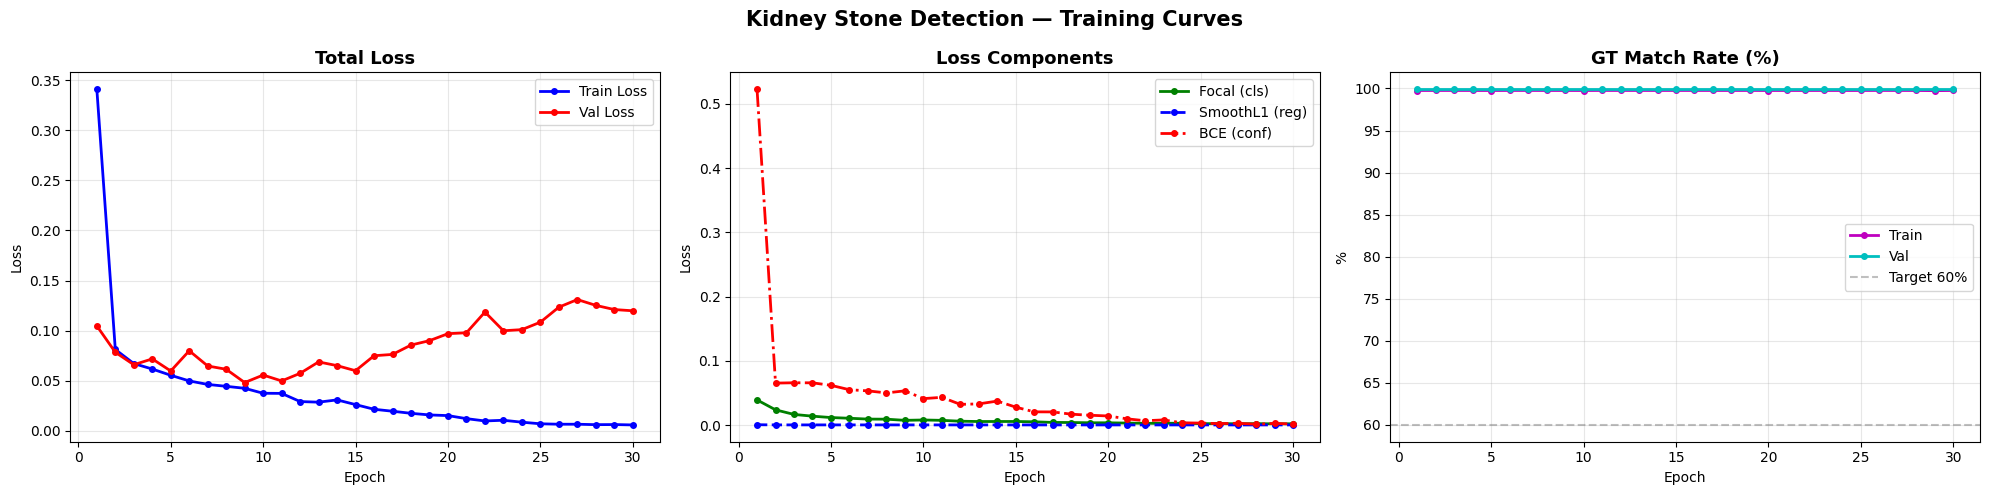

✅ Loss curves saved
⏳ Collecting predictions for PR curve...
  GAT  — total preds: 1260  positives: 1243
  YOLO — total preds: 1470  positives: 1429


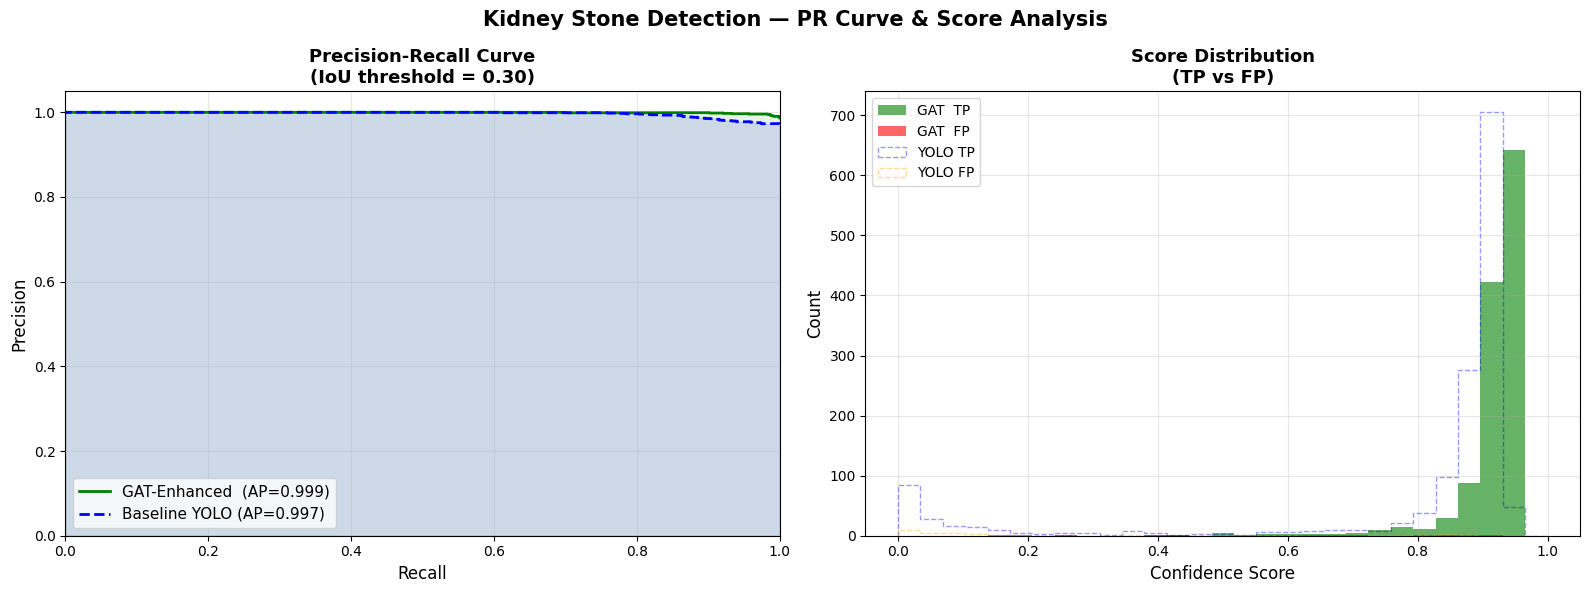

✅ PR curve saved → /kaggle/working/kidney_pr_curve.png


In [22]:
# ─── Cell 23: Loss Curve, PR Curve & Evaluation Plots ───────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

# ── 1. Loss & Match Rate Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs = range(1, len(history['train_loss']) + 1)

# Loss curve
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', lw=2, ms=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   lw=2, ms=4)
axes[0].set_title('Total Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss components
axes[1].plot(epochs, history['train_cls'],  'g-o',  label='Focal (cls)',    lw=2, ms=4)
axes[1].plot(epochs, history['train_reg'],  'b--o', label='SmoothL1 (reg)', lw=2, ms=4)
axes[1].plot(epochs, history['train_conf'], 'r-.o', label='BCE (conf)',      lw=2, ms=4)
axes[1].set_title('Loss Components', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Match rate
axes[2].plot(epochs, [m*100 for m in history['match_rate']],     'm-o', label='Train', lw=2, ms=4)
axes[2].plot(epochs, [m*100 for m in history['val_match_rate']], 'c-o', label='Val',   lw=2, ms=4)
axes[2].axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='Target 60%')
axes[2].set_title('GT Match Rate (%)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('%')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Kidney Stone Detection — Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/kidney_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curves saved')


# ── 2. Collect predictions for PR curve ───────────────────────────────────────
print('⏳ Collecting predictions for PR curve...')
set_eval_mode(model)

all_scores  = []   # confidence scores from GAT model
all_labels  = []   # 1 = matched GT (TP), 0 = no match (FP)

# Also collect baseline YOLO scores for comparison
baseline_yolo  = YOLO(BEST_YOLO_PATH)
base_scores    = []
base_labels    = []

IOU_THRESH = 0.30

with torch.no_grad():
    for batch_imgs, batch_targets in test_loader:
        batch_imgs  = batch_imgs.to(DEVICE)
        predictions = model(batch_imgs)

        for pred, tgt in zip(predictions, batch_targets):
            gt_boxes = tgt['boxes'].to(DEVICE)
            pb       = pred['boxes']
            ps       = pred['scores']

            if pb.shape[0] == 0:
                continue

            if gt_boxes.shape[0] == 0:
                # All predictions are FP
                all_scores.extend(ps.cpu().tolist())
                all_labels.extend([0] * pb.shape[0])
                continue

            iou      = ops.box_iou(pb.clamp(0,1), gt_boxes.clamp(0,1))
            max_iou  = iou.max(dim=1).values

            for score, iou_val in zip(ps.cpu().tolist(), max_iou.cpu().tolist()):
                all_scores.append(score)
                all_labels.append(1 if iou_val >= IOU_THRESH else 0)

# Baseline YOLO PR data
for img_path in val_imgs:
    # Load corresponding target
    lbl_path  = TRAIN_LBL_DIR / (Path(img_path).stem + '.txt')
    gt_boxes  = []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id         = int(float(parts[0]))
                cx, cy, bw, bh = map(float, parts[1:5])
                gt_boxes.append([cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2])

    gt_t     = torch.tensor(gt_boxes, dtype=torch.float32) if gt_boxes else torch.zeros(0,4)
    yolo_res = baseline_yolo(str(img_path), conf=0.01, verbose=False)[0]

    if yolo_res.boxes is None or len(yolo_res.boxes) == 0:
        continue

    pb = yolo_res.boxes.xyxyn.cpu()
    ps = yolo_res.boxes.conf.cpu()

    if gt_t.shape[0] == 0:
        base_scores.extend(ps.tolist())
        base_labels.extend([0] * pb.shape[0])
        continue

    iou     = ops.box_iou(pb.clamp(0,1), gt_t.clamp(0,1))
    max_iou = iou.max(dim=1).values

    for score, iou_val in zip(ps.tolist(), max_iou.tolist()):
        base_scores.append(score)
        base_labels.append(1 if iou_val >= IOU_THRESH else 0)

print(f'  GAT  — total preds: {len(all_scores)}  positives: {sum(all_labels)}')
print(f'  YOLO — total preds: {len(base_scores)}  positives: {sum(base_labels)}')


# ── 3. PR Curve Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: PR Curve ─────────────────────────────────────────────────────────
if sum(all_labels) > 0 and sum(base_labels) > 0:
    gat_prec,  gat_rec,  _ = precision_recall_curve(all_labels,  all_scores)
    base_prec, base_rec, _ = precision_recall_curve(base_labels, base_scores)
    gat_ap  = average_precision_score(all_labels,  all_scores)
    base_ap = average_precision_score(base_labels, base_scores)

    axes[0].plot(gat_rec,  gat_prec,  'g-', lw=2,
                 label=f'GAT-Enhanced  (AP={gat_ap:.3f})')
    axes[0].plot(base_rec, base_prec, 'b--', lw=2,
                 label=f'Baseline YOLO (AP={base_ap:.3f})')
    axes[0].fill_between(gat_rec,  gat_prec,  alpha=0.1, color='green')
    axes[0].fill_between(base_rec, base_prec, alpha=0.1, color='blue')
    axes[0].set_xlabel('Recall',    fontsize=12)
    axes[0].set_ylabel('Precision', fontsize=12)
    axes[0].set_title('Precision-Recall Curve\n(IoU threshold = 0.30)',
                      fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])
    axes[0].grid(alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Not enough positive samples\nto compute PR curve',
                 ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')

# ── Panel 2: Score Distribution ───────────────────────────────────────────────
gat_pos  = [s for s, l in zip(all_scores,  all_labels)  if l == 1]
gat_neg  = [s for s, l in zip(all_scores,  all_labels)  if l == 0]
base_pos = [s for s, l in zip(base_scores, base_labels) if l == 1]
base_neg = [s for s, l in zip(base_scores, base_labels) if l == 0]

bins = np.linspace(0, 1, 30)
axes[1].hist(gat_pos,  bins=bins, alpha=0.6, color='green', label='GAT  TP')
axes[1].hist(gat_neg,  bins=bins, alpha=0.6, color='red',   label='GAT  FP')
axes[1].hist(base_pos, bins=bins, alpha=0.4, color='blue',  label='YOLO TP', linestyle='--', histtype='step', lw=2)
axes[1].hist(base_neg, bins=bins, alpha=0.4, color='orange',label='YOLO FP', linestyle='--', histtype='step', lw=2)
axes[1].set_xlabel('Confidence Score', fontsize=12)
axes[1].set_ylabel('Count',            fontsize=12)
axes[1].set_title('Score Distribution\n(TP vs FP)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Kidney Stone Detection — PR Curve & Score Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/kidney_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PR curve saved → /kaggle/working/kidney_pr_curve.png')